# 46 — Three modeling extensions: forgetting, Poisson arrival, and a coarse world

nb44 found a **wall**: with pure accumulation (no forgetting) a population locks onto the first
theory and never catches a moving world. That wall motivated three changes to the *underlying
model* — each one a knob the network-epistemology literature usually installs by hand, here given a
mechanism:

1. **Forgetting `ω`** — the system *relaxes its precision* over time: each step the accumulated
   evidence decays back toward the prior, `Π ← Π_prior + ω(Π − Π_prior)` (the paper's forgetting
   factor, now in `simulation.run_simulation`). It **breaks the wall** (the population re-tracks)
   and turns conviction into **motivated persistence** (lock-in becomes *earned*, not automatic).
2. **Poisson arrival `λ`** — *when* the agent proposes a new commitment is itself a Poisson process
   of rate `λ`, so structural discovery is a random **waiting time** (the paper's node-arrival
   model) rather than a fixed instant.
3. **A coarse world** — the true environment is far richer than the agent's coarse Bayes net, so
   the answer is **resolved only slowly** — and under forgetting, never fully.

> ### ⚠️ Disclaimers
> * Stylized Gaussian models, not real cosmology. The point is the *mechanism*, not the numbers.
> * `ω`, `λ`, and sensing resolution are **dials** here; inferring them (volatility estimation for
>   `ω`, a real proposal grammar for `λ`) is left to future work, exactly as the paper says.
> * This notebook **loads** arrays saved by `scripts/run_cosmology_forgetting.py`,
>   `…_poisson.py`, and `…_coarse_world.py` — run those three first.

In [1]:
%matplotlib inline
import sys, pathlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3})

ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / 'results').exists() else ROOT.parent
R = ROOT / 'results'
F = np.load(R / 'cosmology_forgetting'   / 'simulation_arrays.npz', allow_pickle=True)
P = np.load(R / 'cosmology_poisson'      / 'simulation_arrays.npz', allow_pickle=True)
W = np.load(R / 'cosmology_coarse_world' / 'simulation_arrays.npz', allow_pickle=True)
EPOCHS = [str(x) for x in F['epoch_names']]; COMMS = [str(x) for x in F['comm_labels']]
T1, T2 = int(F['T1']), int(F['T2'])
print('loaded forgetting / poisson / coarse-world arrays; epochs =', EPOCHS)

loaded forgetting / poisson / coarse-world arrays; epochs = ['dark_matter', 'modified_gravity', 'scale_variant_laws']


## 1 — Forgetting breaks the wall (and makes lock-in *earned*)

**The wall.** With `ω = 1` (no forgetting) the lever-free population is stuck: after epoch 0 the
fraction of agents on the *current* true theory collapses to ~0 and stays there — early evidence is
simply too heavy to overturn. **Turn on forgetting** (`ω < 1`) and the population **re-tracks** each
successive theory: old evidence leaks at rate `ω` (effective memory ~`1/(1−ω)`), so the current
epoch can win. The cost is confidence — more forgetting means lower steady-state precision. There is
a sweet spot.

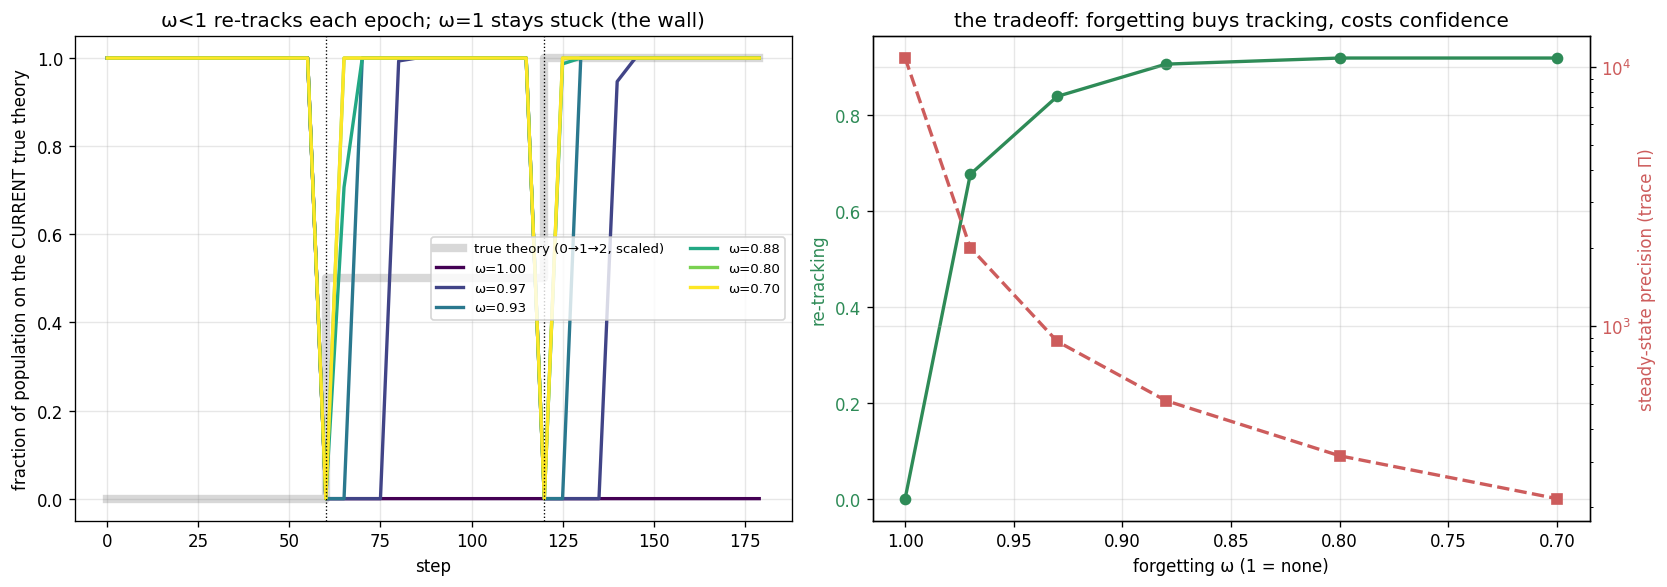

by-epoch frac-on-true: {1.0: [np.float64(1.0), np.float64(0.0), np.float64(0.0)], 0.97: [np.float64(1.0), np.float64(0.67), np.float64(0.69)], 0.93: [np.float64(1.0), np.float64(0.83), np.float64(0.85)], 0.88: [np.float64(1.0), np.float64(0.89), np.float64(0.92)], 0.8: [np.float64(1.0), np.float64(0.92), np.float64(0.92)], 0.7: [np.float64(1.0), np.float64(0.92), np.float64(0.92)]}


In [2]:
omegas = F['omegas']; snap_t = F['snap_t']; true_e = F['true_epoch']
fot = F['frac_on_true']            # (n_omega, S)
fig, (a0, a1) = plt.subplots(1, 2, figsize=(14, 5))
a0.step(snap_t, true_e/2.0, where='post', color='0.4', lw=5, alpha=0.25, label='true theory (0→1→2, scaled)')
for i, om in enumerate(omegas):
    a0.plot(snap_t, fot[i], lw=2, color=cm.viridis(i/(len(omegas)-1)), label=f'ω={om:.2f}')
for tt in (T1, T2): a0.axvline(tt, color='k', ls=':', lw=0.8)
a0.set_xlabel('step'); a0.set_ylabel('fraction of population on the CURRENT true theory')
a0.set_ylim(-0.05, 1.05); a0.legend(fontsize=8, ncol=2)
a0.set_title('ω<1 re-tracks each epoch; ω=1 stays stuck (the wall)')

by_ep = F['by_epoch']               # (n_omega, 3)
track12 = by_ep[:, 1:].mean(axis=1)
a1.plot(omegas, track12, 'o-', color='seagreen', lw=2, label='re-tracking (frac-on-true, ep 1&2)')
a1.set_xlabel('forgetting ω (1 = none)'); a1.set_ylabel('re-tracking', color='seagreen')
a1.invert_xaxis(); a1.tick_params(axis='y', labelcolor='seagreen')
a1b = a1.twinx()
a1b.plot(omegas, F['mean_prec'], 's--', color='indianred', lw=2, label='precision')
a1b.set_ylabel('steady-state precision (trace Π)', color='indianred'); a1b.set_yscale('log')
a1b.tick_params(axis='y', labelcolor='indianred'); a1.set_title('the tradeoff: forgetting buys tracking, costs confidence')
plt.tight_layout(); plt.show()
print('by-epoch frac-on-true:', {float(o): list(np.round(b,2)) for o,b in zip(omegas, by_ep)})

**Motivated persistence.** Forgetting also changes *conviction*. Without forgetting the value
tilt accumulates without bound, so **any** positive conviction eventually dominates — lock-in is
automatic. With forgetting the tilt saturates, so it only holds if it beats the (also-saturated)
per-step evidence: lock-in becomes a **threshold on conviction**. Below the threshold a committed
bloc re-tracks; above it, the bloc stays on its home theory *even though the evidence that supported
it has leaked away* — a belief wanted-true after its reasons are gone.

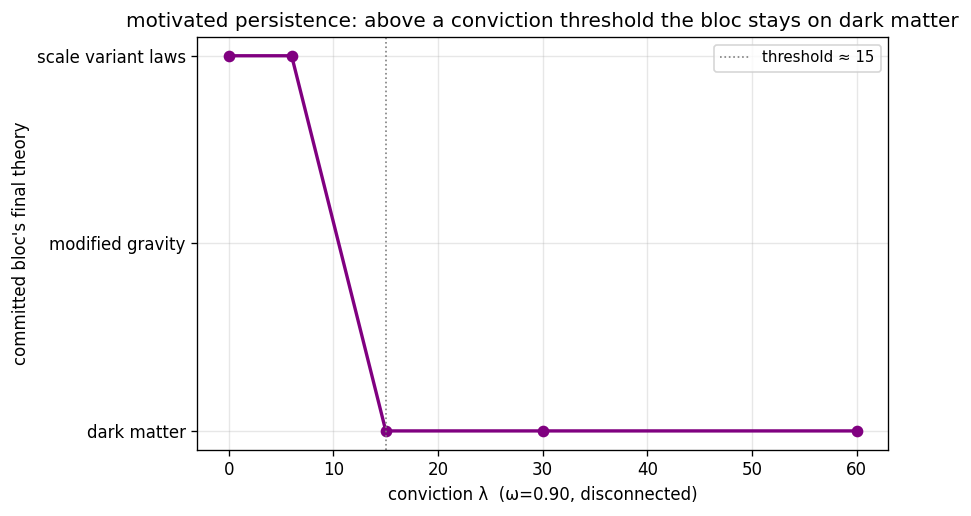

conviction → [np.float64(0.0), np.float64(6.0), np.float64(15.0), np.float64(30.0), np.float64(60.0)]  bloc-final-theory → [2, 2, 0, 0, 0]


In [3]:
pc = P  # (alias guard) -- use the forgetting file's persistence sweep
conv = F['persist_conv']; cons_end = F['persist_cons_end']
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.plot(conv, cons_end, 'o-', color='purple', lw=2)
locked = conv[(cons_end == 0) & (conv > 0)]
if locked.size: ax.axvline(locked.min(), color='0.5', ls=':', lw=1, label=f'threshold ≈ {locked.min():.0f}')
ax.set_xlabel('conviction λ  (ω=0.90, disconnected)'); ax.set_yticks([0,1,2])
ax.set_yticklabels([e.replace('_',' ') for e in EPOCHS]); ax.set_ylabel("committed bloc's final theory")
ax.set_title('motivated persistence: above a conviction threshold the bloc stays on dark matter')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()
print('conviction →', list(conv), ' bloc-final-theory →', list(int(x) for x in cons_end))

## 2 — Poisson arrival: structural discovery as a waiting time

In Lens A (nb45 §6) the agent wakes an unconceived `dark_energy` node the moment its residual floor
clears the trigger. But *when* a community looks for a new commitment is itself contingent. Modeling
node arrival as a **Poisson process of rate `λ`** makes discovery a random **waiting time**: the
cause appears at `T2`, the floor builds, and the agent must *happen to propose* (an arrival).
Faster proposers (high `λ`) discover dark energy soon after it appears; slow proposers discover it
late, and at very low `λ` some never discover it within the horizon. The mean delay tracks `≈ 1/λ`.

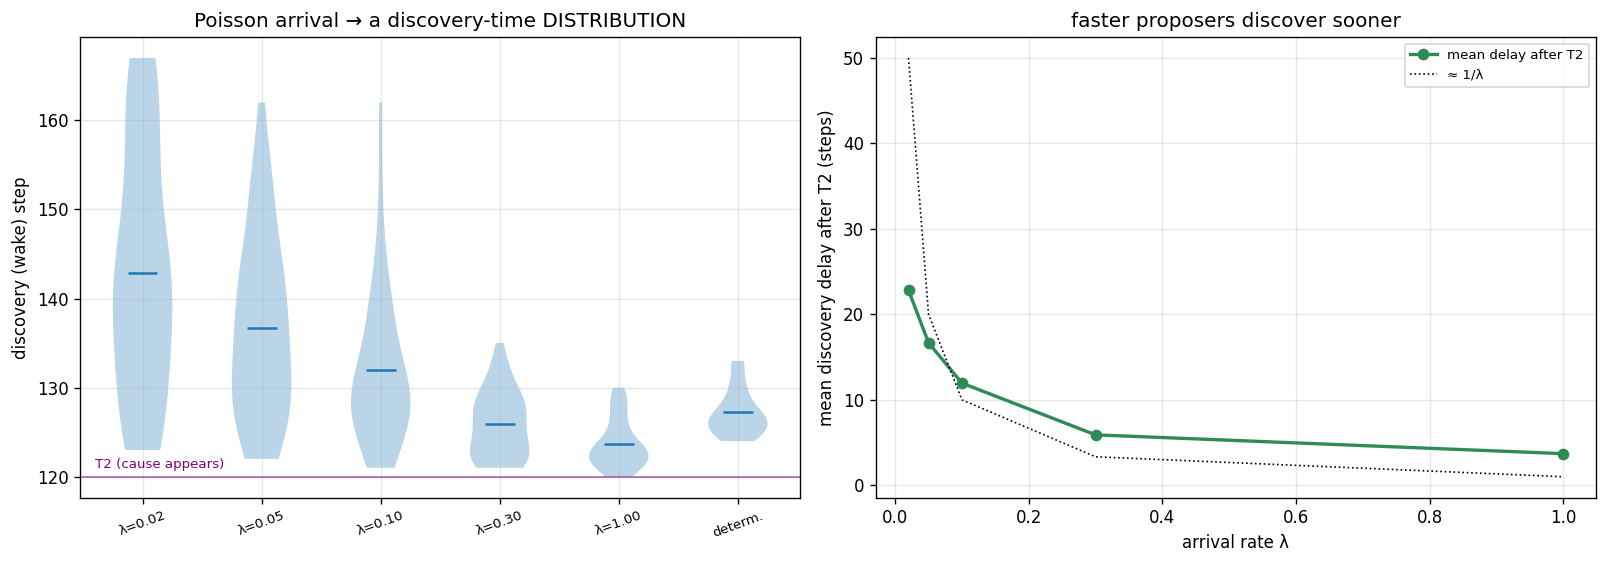

wake fraction by λ: {0.02: 0.725, 0.05: 0.975, 0.1: 1.0, 0.3: 1.0, 1.0: 1.0}  (low λ → some never discover within the horizon)


In [4]:
rates = P['rates']; n_rates = len(rates)
wts = [P[f'wake_times_{i}'] for i in range(n_rates)]
det = P['det_wake_times']; T2p = int(P['T2'])
fig, (a0, a1) = plt.subplots(1, 2, figsize=(13.5, 4.8))
data = [w for w in wts if w.size] + ([det] if det.size else [])
labels = [f'λ={r:.2f}' for r, w in zip(rates, wts) if w.size] + (['determ.'] if det.size else [])
a0.violinplot(data, showmeans=True, showextrema=False)
a0.axhline(T2p, color='purple', lw=1, alpha=0.6); a0.text(0.6, T2p+1, 'T2 (cause appears)', color='purple', fontsize=8)
a0.set_xticks(range(1, len(labels)+1)); a0.set_xticklabels(labels, rotation=20, fontsize=8)
a0.set_ylabel('discovery (wake) step'); a0.set_title('Poisson arrival → a discovery-time DISTRIBUTION')
a1.plot(rates, P['mean_delay'], 'o-', color='seagreen', lw=2, label='mean delay after T2')
a1.plot(rates, 1.0/rates, 'k:', lw=1, label='≈ 1/λ')
a1.set_xlabel('arrival rate λ'); a1.set_ylabel('mean discovery delay after T2 (steps)')
a1.set_title('faster proposers discover sooner'); a1.legend(fontsize=8)
plt.tight_layout(); plt.show()
print('wake fraction by λ:', {float(r): float(f) for r,f in zip(rates, P['wake_fraction'])},
      ' (low λ → some never discover within the horizon)')

## 3 — A complex world a coarse net resolves only slowly

The cosmology menu is **coarse** (a handful of commitments), but a world can be far richer. Here the
true world is a complex `M`-parameter Gaussian (`K` latent factors → correlated, individually
ambiguous directions). A coarse agent senses only `res` random aggregate combinations per step and
reconstructs the world state. **Coarser → slower:** the time to resolve the world (mean error < ε)
grows sharply as `res` shrinks, and below some resolution it never finishes within the horizon. *The
complex answer takes a while precisely because the net is coarse.*

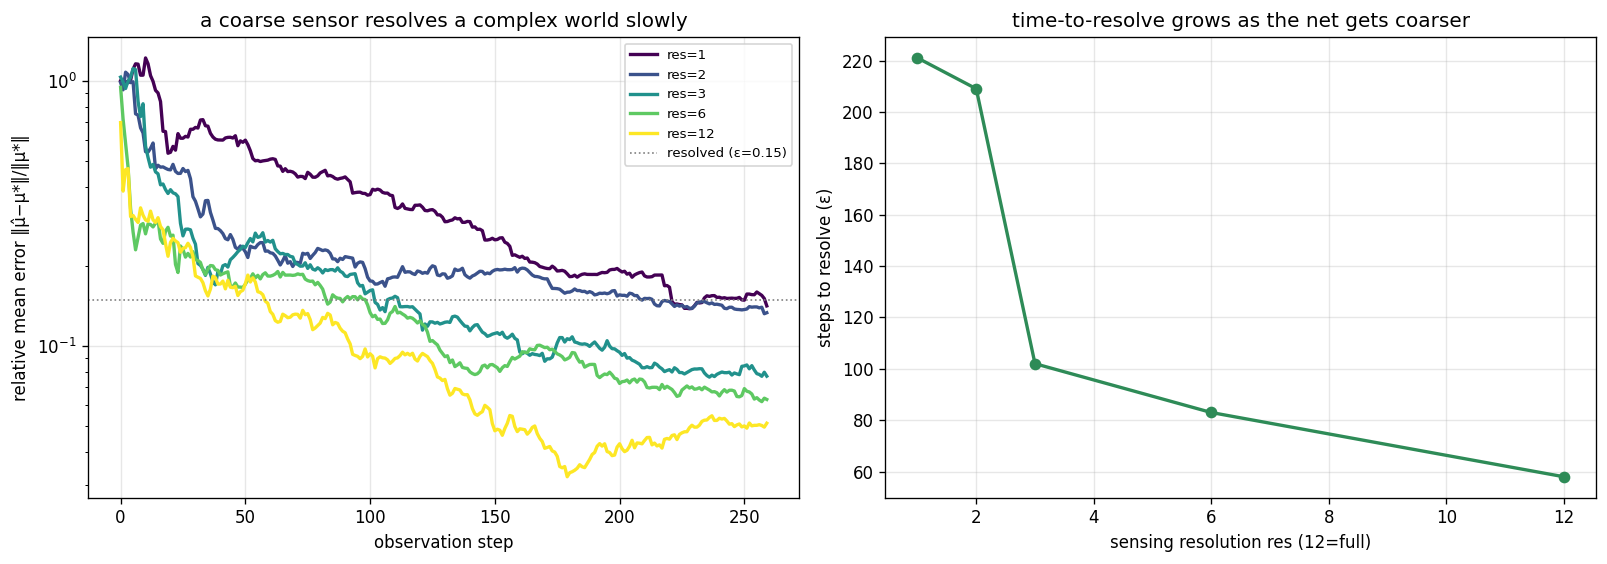

time-to-resolve by res: {1: 221, 2: 209, 3: 102, 6: 83, 12: 58}


In [5]:
err_res = W['err_by_res']; res_grid = W['res_grid']; eps = float(W['eps'])
t_res = W['t_resolve']; n_steps = err_res.shape[1]
fig, (a0, a1) = plt.subplots(1, 2, figsize=(13.5, 4.8))
for i, res in enumerate(res_grid):
    a0.plot(err_res[i], lw=2, color=cm.viridis(i/(len(res_grid)-1)), label=f'res={res}')
a0.axhline(eps, color='grey', ls=':', lw=1, label=f'resolved (ε={eps})')
a0.set_yscale('log'); a0.set_xlabel('observation step'); a0.set_ylabel('relative mean error ‖μ̂−μ*‖/‖μ*‖')
a0.set_title('a coarse sensor resolves a complex world slowly'); a0.legend(fontsize=8)
a1.plot(res_grid, t_res, 'o-', color='seagreen', lw=2)
a1.set_xlabel(f'sensing resolution res ({int(res_grid[-1])}=full)'); a1.set_ylabel('steps to resolve (ε)')
a1.set_title('time-to-resolve grows as the net gets coarser')
plt.tight_layout(); plt.show()
print('time-to-resolve by res:', {int(r): int(t) for r,t in zip(res_grid, t_res)})

**Forgetting floors it.** Add the same forgetting `ω` to a fixed coarse sensor and the complex
world is **never fully resolved** — the mean error plateaus at a floor that rises as `ω` falls. A net
that both under-senses *and* forgets cannot pin down a complex world: there is no clear answer for
it to settle on. (Honest caveat: in this linear-Gaussian model the precision deposit `HᵀH` is
operator-set, so what the agent resolves here is the world **state**, not the off-diagonal covariance
structure — the same caveat Lens B reports.)

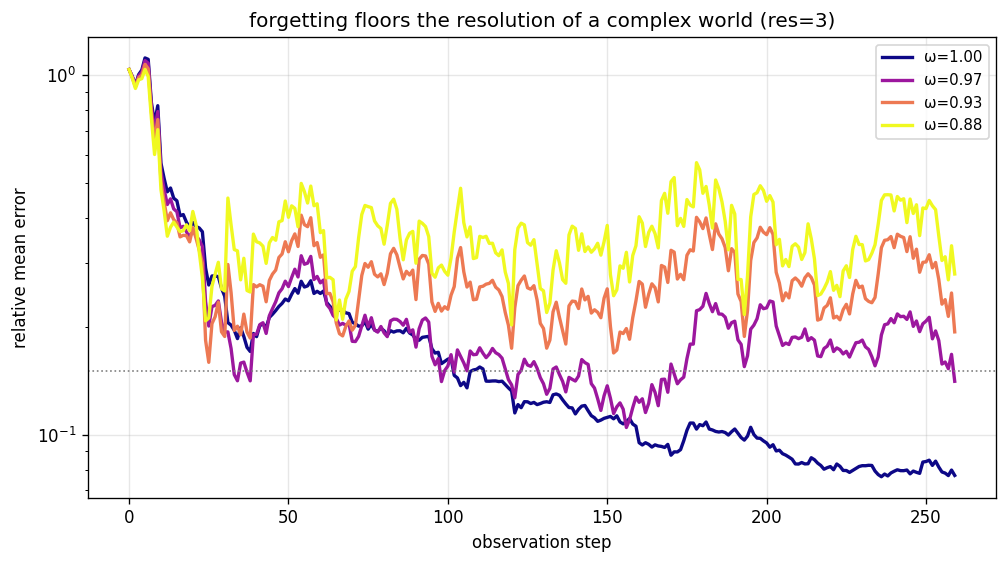

final error floor by ω: {1.0: 0.07705718737755736, 0.97: 0.14081435297475275, 0.93: 0.19324520526089414, 0.88: 0.28000307158020576}


In [6]:
err_om = W['err_by_omega']; om_grid = W['omega_grid']; floors = W['floors']
fig, ax = plt.subplots(figsize=(8.5, 4.8))
for i, om in enumerate(om_grid):
    ax.plot(err_om[i], lw=2, color=cm.plasma(i/(len(om_grid)-1)), label=f'ω={om:.2f}')
ax.axhline(eps, color='grey', ls=':', lw=1)
ax.set_yscale('log'); ax.set_xlabel('observation step'); ax.set_ylabel('relative mean error')
ax.set_title(f'forgetting floors the resolution of a complex world (res={int(W["res_for_omega"])})')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()
print('final error floor by ω:', {float(o): float(f) for o,f in zip(om_grid, floors)})

## Verdict

Three knobs the network-epistemology models usually *post*, here given a mechanism and a consequence:

* **Forgetting `ω`** (precision relaxation) is the missing ingredient behind the no-forgetting wall:
  with it the population **re-tracks** a moving world, and conviction becomes **motivated
  persistence** — lock-in is now *earned* (a conviction threshold) rather than automatic.
* **Poisson arrival `λ`** makes structural discovery a **waiting time** — exploration as a *rate*,
  not a tuned bonus; too slow a rate and the unconceived node is never found in time.
* **A coarse world** shows the cost of a coarse Bayes net directly: a complex environment is
  resolved only **slowly**, and under forgetting **never fully** — the honest limit of a bounded,
  forgetful, under-sensing learner.

Together they sit underneath the cosmology story of nb44–45: `ω` (memory), `λ` (exploration rate),
and resolution (representational coarseness) are the three dials that decide whether a community
tracks a changing world, when it discovers what it lacks, and how completely it can ever know a world
richer than its model. **Caveats stand:** stylized Gaussian models; the dials are swept, not inferred;
and precision structure is operator-set, so 'resolving' here means the world's state.